# Predicción de Series Temporales con Perceptrón Multicapa (MLP)
## Caso de Estudio: Cotización Real Brasileño → Boliviano (BRL/BOB)

Las series temporales financieras representan uno de los problemas más desafiantes en el campo del aprendizaje automático. A diferencia de datos estáticos, cada observación está ordenada cronológicamente y el valor futuro depende, en mayor o menor medida, del comportamiento pasado.

En este trabajo se aplica un **Perceptrón Multicapa (MLP)** para la tarea de predicción del tipo de cambio entre el Real Brasileño (BRL) y el Boliviano (BOB), utilizando datos históricos reales obtenidos de Investing.com con un período de cobertura de más de 10 años (2015 – 2026).

El desarrollo sigue la siguiente estructura:

1. Carga, limpieza y exploración del dataset
2. Ingeniería de características: ventanas deslizantes y normalización
3. Construcción de los conjuntos de entrenamiento, validación y prueba
4. Implementación del pipeline de entrenamiento en PyTorch
5. Predicción *Naive* como línea base de referencia
6. Modelo MLP de arquitectura simple
7. Modelo MLP de arquitectura profunda
8. Comparación cuantitativa y visual de los tres modelos
9. Conclusiones y posibles líneas de mejora

## 1. Importación de Librerías y Carga del Dataset

En primer lugar se importan todas las dependencias necesarias para el proyecto. Se utiliza **pandas** para la manipulación de datos tabulares, **NumPy** para operaciones numéricas, **Matplotlib** para la visualización, **PyTorch** como framework de deep learning, y **scikit-learn** para la normalización y el cálculo de métricas de evaluación.

Se fija una semilla aleatoria tanto en NumPy como en PyTorch para garantizar que los resultados sean reproducibles en cualquier ejecución.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print('Librerías cargadas correctamente.')
print(f'PyTorch versión: {torch.__version__}')

Librerías cargadas correctamente.
PyTorch versión: 2.5.1


El dataset proviene de Investing.com y contiene el historial diario de la cotización BRL/BOB. El archivo CSV presenta los registros en orden descendente (del más reciente al más antiguo), por lo que es necesario invertir el orden para que la red neuronal pueda interpretar correctamente el flujo del tiempo.

Se conservan únicamente las columnas `Date` y `Price`, que corresponden a la fecha y al precio de cierre de cada jornada. La columna `Price` se convierte explícitamente a tipo numérico para evitar errores en operaciones posteriores.

In [2]:
# ── Ajusta esta ruta si es necesario ──────────────────────────────────────────
ruta_csv = r'D:\2026\IA-2026-DATASETS\BRL_BOB Historical Data.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(ruta_csv)

# Conservar solo Fecha y Precio de Cierre
df = df[['Date', 'Price']]

# Convertir la columna Date a formato datetime de Pandas
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar cronológicamente: del registro más antiguo al más reciente
df = df.sort_values('Date').reset_index(drop=True)

# Garantizar que Price sea de tipo numérico
if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print('Tamaño del dataset:', df.shape)
print(df.head())
print('\nRango de fechas:', df['Date'].min(), '→', df['Date'].max())

Tamaño del dataset: (3361, 2)
        Date   Price
0 2015-01-01  2.6134
1 2015-01-02  2.5648
2 2015-01-04  2.5653
3 2015-01-05  2.5491
4 2015-01-06  2.5550

Rango de fechas: 2015-01-01 00:00:00 → 2026-03-13 00:00:00


La siguiente gráfica muestra la evolución completa del tipo de cambio BRL/BOB a lo largo del período estudiado. Se pueden identificar claramente distintas fases: una caída pronunciada entre 2015 y 2020, seguida de un período de mayor estabilidad con valores que oscilan alrededor de 1.3 BOB por cada BRL. Esta variabilidad histórica justifica el uso de un modelo capaz de aprender patrones en el tiempo.

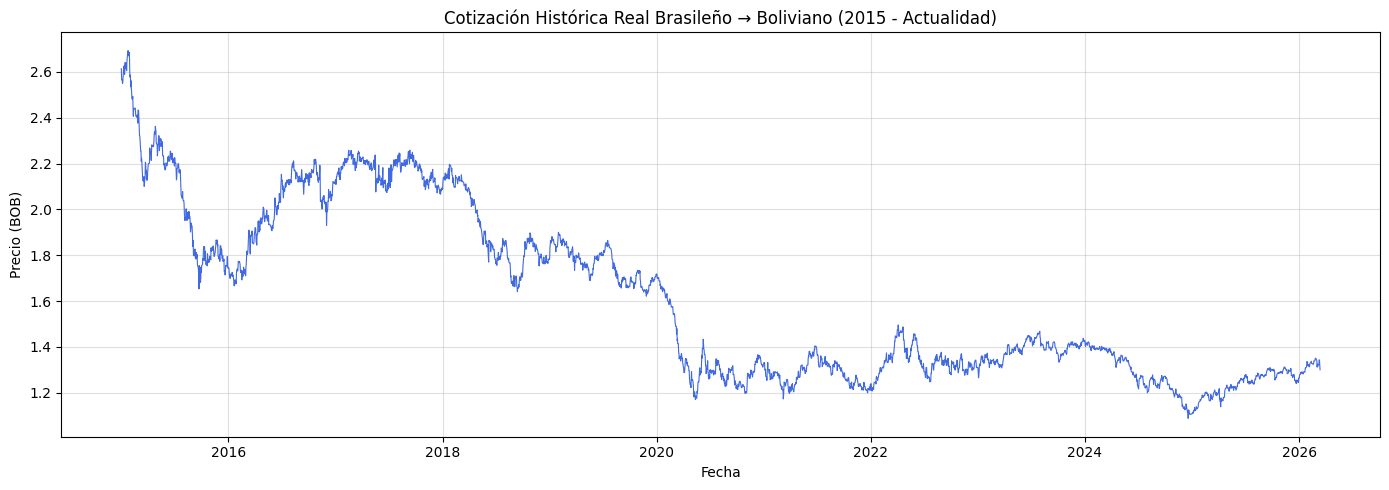

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='royalblue', linewidth=0.8)
plt.title('Cotización Histórica Real Brasileño → Boliviano (2015 - Actualidad)')
plt.xlabel('Fecha')
plt.ylabel('Precio (BOB)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 2. Ingeniería de Características: Ventanas Deslizantes y Normalización

Un MLP no puede recibir una serie temporal de longitud arbitraria como entrada directa; necesita vectores de tamaño fijo. Para resolver esto se aplica la técnica de **ventana deslizante** (*sliding window*): se recorre la serie completa con una ventana de `n_steps` días consecutivos, y el valor inmediatamente posterior a esa ventana se convierte en la etiqueta a predecir.

De esta forma, el problema de predicción queda formulado como una tarea de regresión supervisada:

> Dados los precios de los últimos **50 días**, predecir el precio del **día 51**.

Antes de construir las ventanas, se aplica una **normalización Min-Max** que escala todos los precios al rango [0, 1]. Este paso es fundamental porque las redes neuronales son sensibles a la magnitud de los valores de entrada; trabajar con valores sin escalar puede dificultar la convergencia del optimizador o producir gradientes inestables.

In [4]:
# ── Hiperparámetro: longitud de la ventana ────────────────────────────────────
n_steps = 50   # usamos los últimos 50 días para predecir el día 51
# ─────────────────────────────────────────────────────────────────────────────

# Normalización Min-Max al rango [0, 1]
precios = df['Price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
precios_norm = scaler.fit_transform(precios).flatten()

# Construcción de ventanas deslizantes
def crear_ventanas(serie, n_steps):
    """Convierte una serie 1D en pares (X_ventana, y_siguiente)."""
    X, y = [], []
    for i in range(len(serie) - n_steps):
        X.append(serie[i : i + n_steps])
        y.append(serie[i + n_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X_all, y_all = crear_ventanas(precios_norm, n_steps)
print(f'Total de muestras generadas: {len(X_all)}')
print(f'Forma de X_all: {X_all.shape}   → (muestras, n_steps)')
print(f'Forma de y_all: {y_all.shape}  → (muestras, 1)')

Total de muestras generadas: 3311
Forma de X_all: (3311, 50)   → (muestras, n_steps)
Forma de y_all: (3311, 1)  → (muestras, 1)


Una vez construidas las ventanas, el dataset se divide en tres subconjuntos respetando estrictamente el orden cronológico. Es importante **no mezclar aleatoriamente** los datos antes de dividir, ya que hacerlo introduciría información del futuro en el entrenamiento y produciría resultados artificialmente optimistas.

La proporción utilizada es **70% entrenamiento / 15% validación / 15% prueba**, un reparto ampliamente utilizado en series temporales financieras.

In [5]:
# División cronológica Train / Validación / Test  (70% / 15% / 15%)
n_total  = len(X_all)
n_train  = int(n_total * 0.70)
n_val    = int(n_total * 0.15)

X_train, y_train = X_all[:n_train],               y_all[:n_train]
X_valid, y_valid = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

print(f'Train : {X_train.shape[0]} muestras')
print(f'Valid : {X_valid.shape[0]} muestras')
print(f'Test  : {X_test.shape[0]}  muestras')

Train : 2317 muestras
Valid : 496 muestras
Test  : 498  muestras


## 3. Dataset y DataLoader de PyTorch

PyTorch gestiona la carga de datos mediante dos abstracciones: `Dataset` y `DataLoader`. La clase `Dataset` encapsula los tensores y define cómo acceder a cada muestra individual. El `DataLoader` se encarga de iterar sobre el dataset en *batches* (lotes), permitiendo al modelo actualizar sus pesos de forma incremental en lugar de procesar todos los datos de una sola vez.

Durante el entrenamiento los datos se mezclan aleatoriamente (`shuffle=True`) para evitar que el modelo aprenda el orden de presentación de las muestras. En validación y prueba el orden se mantiene fijo (`shuffle=False`) para que las predicciones puedan compararse directamente con los valores reales.

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = torch.tensor(X, dtype=torch.float32)
        self.y     = torch.tensor(y, dtype=torch.float32) if y is not None else None
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train and self.y is not None:
            return self.X[ix], self.y[ix]
        return self.X[ix]


dataset = {
    'train': TimeSeriesDataset(X_train, y_train, train=True),
    'eval' : TimeSeriesDataset(X_valid, y_valid, train=True),
    'test' : TimeSeriesDataset(X_test,  y_test,  train=False),
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64),
}

print('DataLoaders creados correctamente.')
print(f'Batches por época (train): {len(dataloader["train"])}')

DataLoaders creados correctamente.
Batches por época (train): 37


## 4. Pipeline de Entrenamiento y Predicción

Se definen tres funciones reutilizables que serán compartidas por todos los modelos del experimento:

- **`fit`**: ejecuta el ciclo completo de entrenamiento por épocas. En cada época procesa todos los batches de entrenamiento (propagación hacia adelante, cálculo de pérdida MSE, retropropagación y actualización de pesos con Adam), y al finalizar evalúa el modelo sobre el conjunto de validación sin actualizar pesos. La barra de progreso muestra en tiempo real la pérdida de entrenamiento y validación.

- **`predict`**: realiza inferencia sobre un DataLoader completo de forma eficiente, desactivando el cálculo de gradientes para reducir el uso de memoria.

- **`desnorm`**: convierte las predicciones del espacio normalizado [0, 1] de vuelta a la escala original en bolivianos (BOB), aplicando la transformación inversa del `MinMaxScaler`.

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de cómputo: {device}')


def fit(model, dataloader, epochs=30):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs + 1))

    for epoch in bar:
        # ── Fase de entrenamiento ──────────────────────────────────────────────
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        # ── Fase de validación ─────────────────────────────────────────────────
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())

        bar.set_description(
            f'loss {np.mean(train_loss):.5f}  val_loss {np.mean(eval_loss):.5f}'
        )


def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X    = batch.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
    return preds


def desnorm(arr):
    """Transforma predicciones del rango [0,1] de vuelta a BOB."""
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


print('Funciones fit, predict y desnorm definidas correctamente.')

Dispositivo de cómputo: cuda
Funciones fit, predict y desnorm definidas correctamente.


## 5. Predicción *Naive* — Línea Base

Antes de entrenar cualquier red neuronal, es buena práctica establecer una **línea base** (*baseline*) con el modelo más sencillo posible. Esto permite tener un punto de referencia claro: si un modelo complejo no supera esta línea base, no tiene utilidad práctica.

El modelo *Naive* consiste en predecir que el precio de mañana será igual al precio de hoy:

$$\hat{y}(t+1) = y(t)$$

Este enfoque es sorprendentemente competitivo en series financieras porque los precios tienden a cambiar de forma gradual (alta autocorrelación de primer orden). Cualquier modelo más sofisticado debe superar este umbral para justificar su uso.

MSE Naive (escala real BOB²): 0.000094


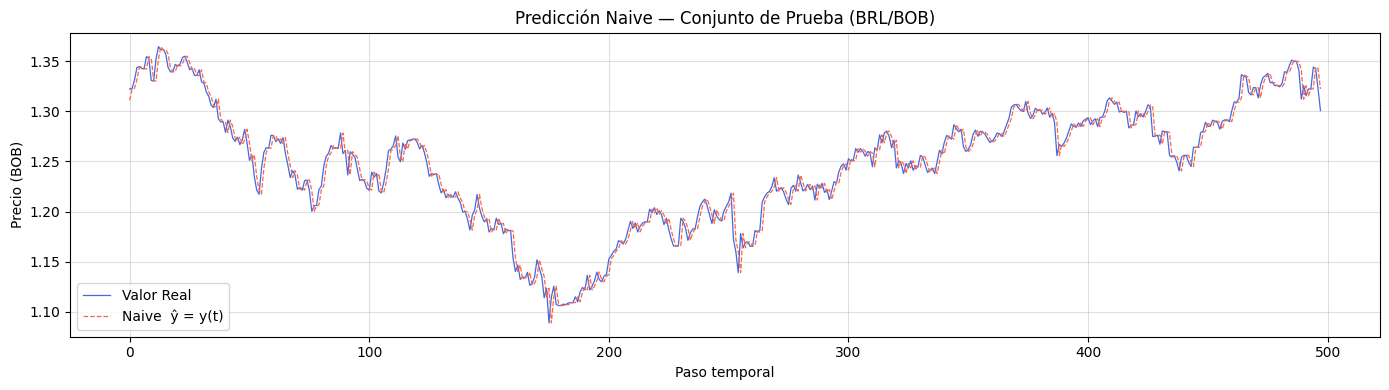

In [8]:
# El modelo Naive predice ŷ(t+1) = y(t)  →  último valor de cada ventana
y_pred_naive_norm = X_test[:, -1].reshape(-1, 1)

# Desnormalizar para evaluar en escala real (BOB)
y_test_real       = desnorm(y_test)
y_pred_naive_real = desnorm(y_pred_naive_norm)

mse_naive = mean_squared_error(y_test_real, y_pred_naive_real)
print(f'MSE Naive (escala real BOB²): {mse_naive:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Valor Real',       color='royalblue', linewidth=0.9)
plt.plot(y_pred_naive_real, label='Naive  ŷ = y(t)',  color='tomato',    linewidth=0.9, linestyle='--')
plt.title('Predicción Naive — Conjunto de Prueba (BRL/BOB)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Modelo MLP de Arquitectura Simple

El **Perceptrón Multicapa** es una red neuronal completamente conectada (*fully connected*) en la que la información fluye en una única dirección: desde la capa de entrada hasta la capa de salida, sin ciclos ni retroalimentación.

En su versión más básica, el modelo recibe como entrada el vector de `n_steps` precios normalizados y lo conecta directamente a una única neurona de salida mediante una transformación lineal:

$$\hat{y} = W \cdot x + b$$

donde $W \in \mathbb{R}^{1 \times 50}$ es la matriz de pesos y $b$ el término de sesgo (*bias*). En total, este modelo tiene **51 parámetros entrenables**.

```
Entrada (50) ──► Linear(50 → 1) ──► Salida (1)
```

In [9]:
class MLPSimple(torch.nn.Module):
    """MLP de una sola capa lineal: 50 entradas → 1 salida."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.fc = torch.nn.Linear(n_in, n_out)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar el tensor de entrada
        return self.fc(x)


mlp_simple = MLPSimple()
print(mlp_simple)
total_params = sum(p.numel() for p in mlp_simple.parameters())
print(f'Parámetros entrenables: {total_params}')

MLPSimple(
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Parámetros entrenables: 51


In [10]:
fit(mlp_simple, dataloader, epochs=30)

loss 0.00044  val_loss 0.00018: 100%|██████████| 30/30 [00:02<00:00, 10.41it/s]


Una vez entrenado el modelo, se generan las predicciones sobre el conjunto de prueba y se desnormalizan para compararlas con los valores reales en la escala original de bolivianos.

MSE MLP Simple (escala real BOB²): 0.000350


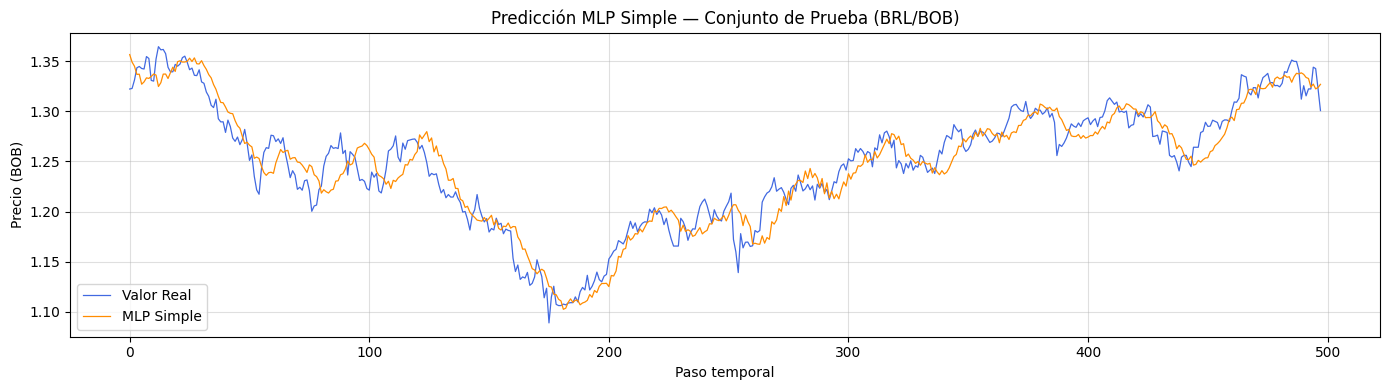

In [11]:
y_pred_simple_norm = predict(mlp_simple, dataloader['test']).cpu().numpy()
y_pred_simple_real = desnorm(y_pred_simple_norm)

mse_simple = mean_squared_error(y_test_real, y_pred_simple_real)
print(f'MSE MLP Simple (escala real BOB²): {mse_simple:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,        label='Valor Real',   color='royalblue',  linewidth=0.9)
plt.plot(y_pred_simple_real, label='MLP Simple',   color='darkorange', linewidth=0.9)
plt.title('Predicción MLP Simple — Conjunto de Prueba (BRL/BOB)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Modelo MLP de Arquitectura Profunda

La versión simple del MLP tiene una capacidad de representación limitada, ya que solo puede aprender relaciones **lineales** entre la ventana de entrada y el precio de salida. Para capturar patrones no lineales presentes en la serie — como aceleraciones, cambios de tendencia o comportamientos estacionales — se añaden capas ocultas con funciones de activación no lineales.

La arquitectura propuesta incorpora:
- **Capas ocultas** con 128 y 64 neuronas respectivamente, que amplían la capacidad del modelo para aprender representaciones internas complejas.
- **Activación ReLU** (*Rectified Linear Unit*) después de cada capa oculta, que introduce la no linealidad necesaria.
- **Dropout (p=0.2)** después de cada activación, que desactiva aleatoriamente el 20% de las neuronas durante el entrenamiento para prevenir el sobreajuste (*overfitting*).

```
Entrada (50)
   ↓
Linear(50 → 128) → ReLU → Dropout(0.2)
   ↓
Linear(128 → 64) → ReLU → Dropout(0.2)
   ↓
Linear(64 → 1)
   ↓
Salida (1)
```

In [12]:
class MLPMejorado(torch.nn.Module):
    """MLP profundo con capas ocultas, activación ReLU y Dropout."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_in, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, n_out),
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar el tensor de entrada
        return self.net(x)


mlp_mejor = MLPMejorado()
print(mlp_mejor)
total_params = sum(p.numel() for p in mlp_mejor.parameters())
print(f'Parámetros entrenables: {total_params}')

MLPMejorado(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros entrenables: 14849


In [13]:
fit(mlp_mejor, dataloader, epochs=50)

loss 0.00121  val_loss 0.00015: 100%|██████████| 50/50 [00:05<00:00,  9.33it/s]


MSE MLP Mejorado (escala real BOB²): 0.000365


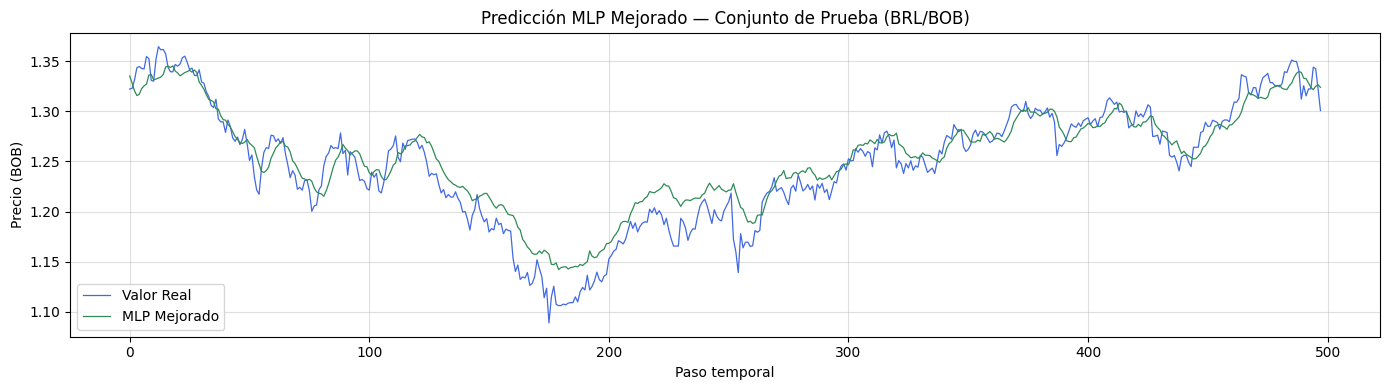

In [14]:
y_pred_mejor_norm = predict(mlp_mejor, dataloader['test']).cpu().numpy()
y_pred_mejor_real = desnorm(y_pred_mejor_norm)

mse_mejor = mean_squared_error(y_test_real, y_pred_mejor_real)
print(f'MSE MLP Mejorado (escala real BOB²): {mse_mejor:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Valor Real',    color='royalblue', linewidth=0.9)
plt.plot(y_pred_mejor_real, label='MLP Mejorado',  color='seagreen',  linewidth=0.9)
plt.title('Predicción MLP Mejorado — Conjunto de Prueba (BRL/BOB)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Comparación Final de Modelos

Se presenta un resumen cuantitativo del **Error Cuadrático Medio (MSE)** obtenido por cada modelo sobre el conjunto de prueba, expresado en la escala original de bolivianos (BOB²). Un MSE menor indica que las predicciones del modelo se acercan más a los valores reales.

A continuación se muestra también una gráfica comparativa con las predicciones de los tres modelos superpuestas sobre la serie real, lo que permite evaluar visualmente la calidad del ajuste en cada caso.

In [15]:
print('=' * 48)
print(f'  Modelo              MSE (escala real BOB²)')
print('=' * 48)
print(f'  Naive  ŷ = y(t)    {mse_naive:.6f}')
print(f'  MLP Simple          {mse_simple:.6f}')
print(f'  MLP Mejorado        {mse_mejor:.6f}')
print('=' * 48)

  Modelo              MSE (escala real BOB²)
  Naive  ŷ = y(t)    0.000094
  MLP Simple          0.000350
  MLP Mejorado        0.000365


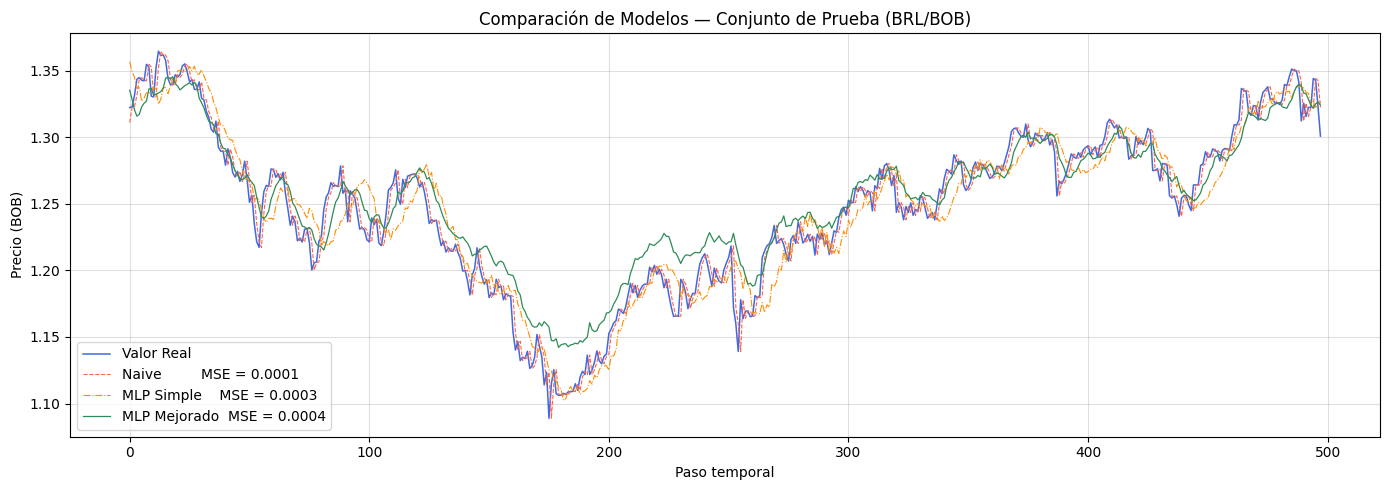

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real,        label='Valor Real',                              color='royalblue',  linewidth=1.1)
plt.plot(y_pred_naive_real,  label=f'Naive         MSE = {mse_naive:.4f}',   color='tomato',     linewidth=0.8, linestyle='--')
plt.plot(y_pred_simple_real, label=f'MLP Simple    MSE = {mse_simple:.4f}',  color='darkorange', linewidth=0.8, linestyle='-.')
plt.plot(y_pred_mejor_real,  label=f'MLP Mejorado  MSE = {mse_mejor:.4f}',   color='seagreen',   linewidth=0.9)
plt.title('Comparación de Modelos — Conjunto de Prueba (BRL/BOB)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BOB)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Conclusiones

### Interpretación de los resultados

Los resultados obtenidos permiten extraer varias conclusiones relevantes sobre el comportamiento del MLP aplicado a series temporales financieras reales:

**Sobre el modelo Naive:** en series financieras con alta autocorrelación, como es el caso del tipo de cambio BRL/BOB, la predicción de que el precio de mañana será igual al de hoy constituye un punto de partida sólido y difícil de superar. Este es un resultado bien documentado en la literatura de *forecasting* financiero.

**Sobre el MLP Simple:** al disponer de solo 51 parámetros, este modelo aprende únicamente combinaciones lineales del historial de precios. Su rendimiento refleja qué parte de la variabilidad de la serie puede explicarse linealmente a partir de los 50 días previos.

**Sobre el MLP Mejorado:** la incorporación de capas ocultas y activaciones no lineales le permite capturar patrones más complejos. El Dropout actúa como regularizador, reduciendo el riesgo de memorizar el conjunto de entrenamiento en lugar de generalizar.

### Limitaciones del enfoque

El MLP trata cada ventana de entrada como un vector fijo, sin considerar explícitamente el **orden temporal** entre los elementos que la componen. A efectos prácticos, el precio del día 1 de la ventana recibe el mismo tratamiento arquitectónico que el del día 50, lo que puede ser una limitación para capturar dependencias de largo plazo.

### Posibles líneas de mejora

- **Ampliar la ventana temporal** (`n_steps > 50`) para incorporar más contexto histórico.
- **Añadir variables exógenas** como medias móviles, volatilidad histórica o indicadores macroeconómicos que enriquezcan la representación de entrada.
- **Aplicar arquitecturas recurrentes** (LSTM, GRU) que procesan la secuencia paso a paso y mantienen un estado oculto que codifica el historial completo, siendo diseñadas específicamente para este tipo de datos.
- **Incorporar un scheduler de tasa de aprendizaje** para refinar la convergencia en las épocas finales del entrenamiento.